# Интерпретируемые методы МО и DL для поддержки риск-ориентированных решений в финансовых системах

**Датасет:** Loan Approval Dataset  
**Целевая переменная:** `loan_status` (0 — отказ, 1 — одобрено)  
**Задача:** бинарная классификация

---
## 1. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
import shap

%matplotlib inline

---
## 2. Загрузка данных

In [2]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

print('Размер train:', train.shape)
print('Размер test:', test.shape)
train.head()

Размер train: (58645, 13)
Размер test: (39098, 12)


,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


---
## 3. Разведочный анализ данных (EDA)


### 3.1 Первичный осмотр

In [3]:
print('Типы данных:')
print(train.dtypes)
print()
print('Базовая статистика:')
train.describe()

Типы данных:
id                              int64
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
loan_status                     int64
dtype: object

Базовая статистика:


,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,58645.000000,5.864500e+04,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000
mean,29322.000000,27.550857,6.404617e+04,4.701015,9217.556518,10.677874,0.159238,5.813556,0.142382
std,16929.497605,6.033216,3.793111e+04,3.959784,5563.807384,3.034697,0.091692,4.029196,0.349445
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,58644.000000,123.000000,1.900000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


**Наблюдения из describe():**
- Максимальный возраст 123 года — явный выброс, реальное значение невозможно
- Максимальный доход 1 900 000 USD — возможный выброс, очень редкое значение
- Распределение дохода скошено вправо: среднее 64 046, максимум 1 900 000
- Процентная ставка в диапазоне 5.42% — 23.22%, выбросов нет

### 3.2 Проверка пропусков

In [4]:
print('Пропущенные значения:')
print(train.isnull().sum())

Пропущенные значения:
id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64


**Вывод:** Пропущенные значения отсутствуют во всех колонках — дополнительная обработка не требуется.

### 3.3 Анализ целевой переменной

Распределение классов:
loan_status
0    50295
1     8350
Name: count, dtype: int64

В процентах:
loan_status
0    85.761787
1    14.238213
Name: proportion, dtype: float64


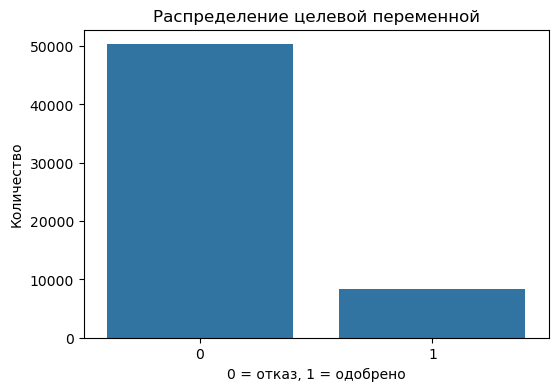

In [5]:
print('Распределение классов:')
print(train['loan_status'].value_counts())
print()
print('В процентах:')
print(train['loan_status'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=train)
plt.title('Распределение целевой переменной')
plt.xlabel('0 = отказ, 1 = одобрено')
plt.ylabel('Количество')
plt.savefig('../figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Вывод:** Наблюдается сильный дисбаланс классов — 85.8% отказов (0) и 14.2% одобрений (1). Отказов почти в 6 раз больше. Это необходимо учесть при обучении моделей.

### 3.4 Распределения числовых признаков

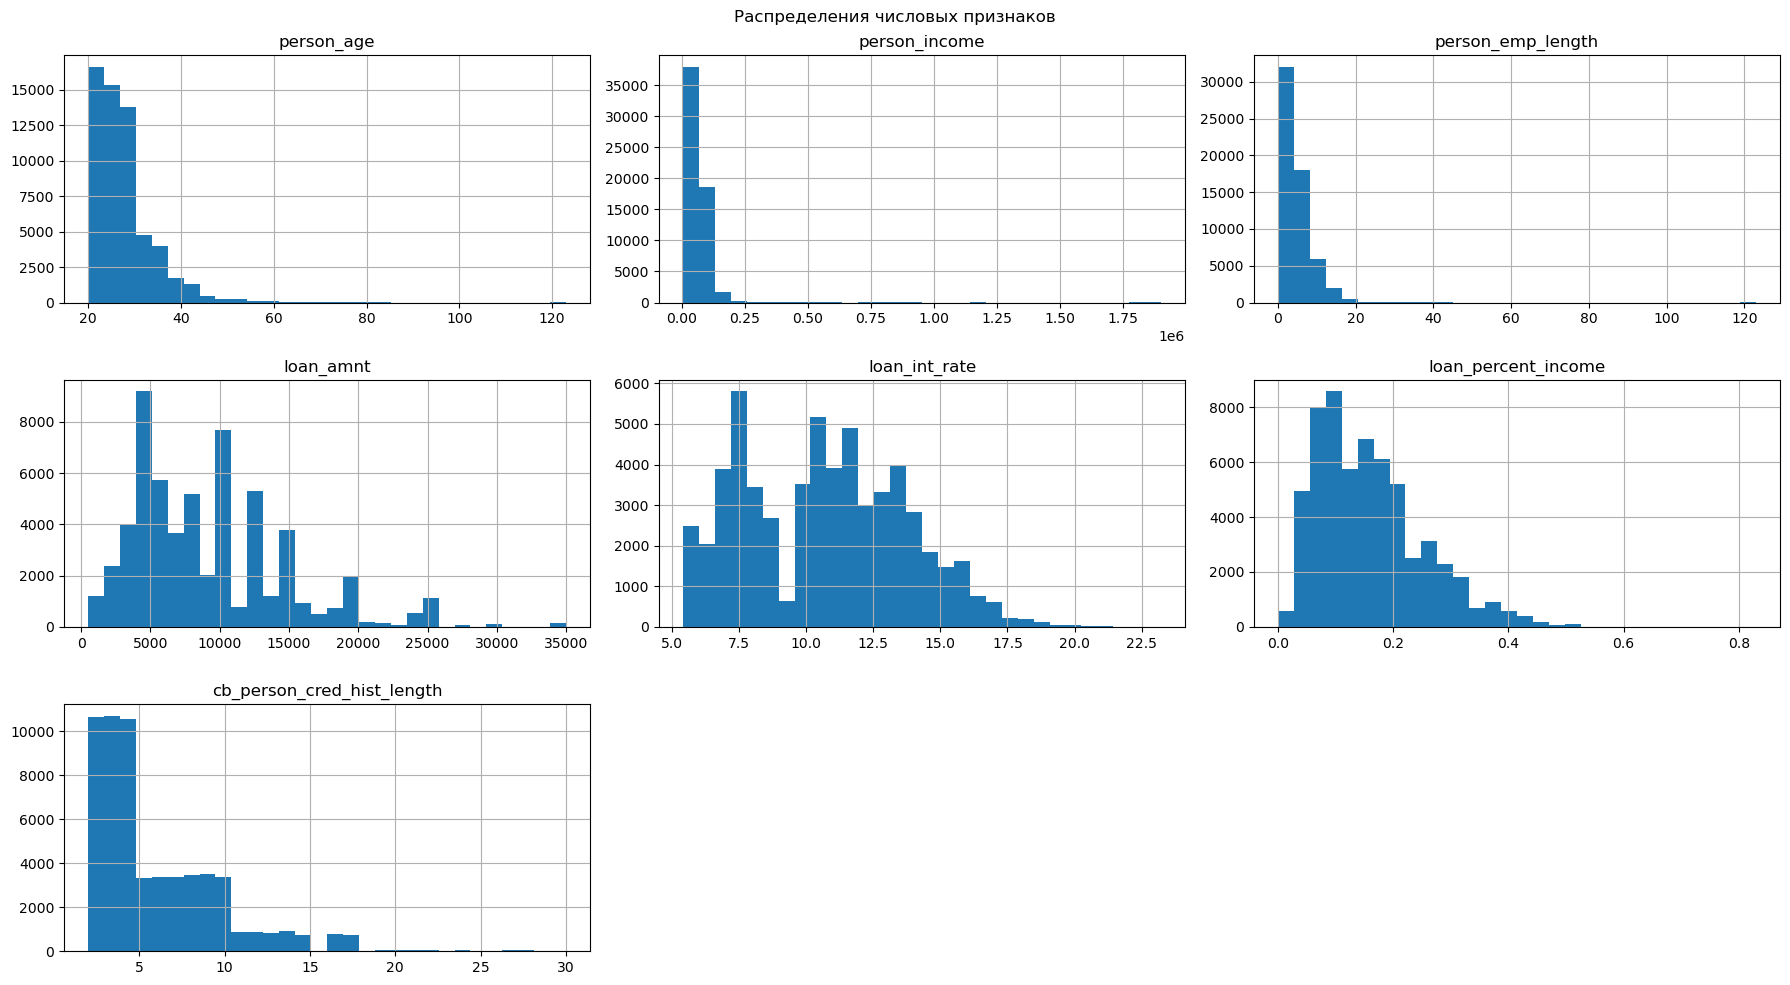

In [6]:
num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length']

train[num_cols].hist(bins=30, figsize=(18, 10))
plt.suptitle('Распределения числовых признаков')
plt.tight_layout()
plt.savefig('../figures/numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Наблюдения:**
- `person_age`: пик на 22-23 годах, хвост до 123 лет (выброс)
- `person_income`: большинство до 200k USD
- `person_emp_length`: большинство работают до 10 лет
- `loan_amnt`: пики на круглых суммах 5000 и 10000 USD
- `loan_int_rate`: три горба — около 7-8%, 10-12% и 13-14%
- `loan_percent_income`: большинство берут кредит на 5-25% от дохода
- `cb_person_cred_hist_length`: ступенчатое распределение по группам 1-5, 5-10, 10-15 лет

### 3.5 Распределения категориальных признаков

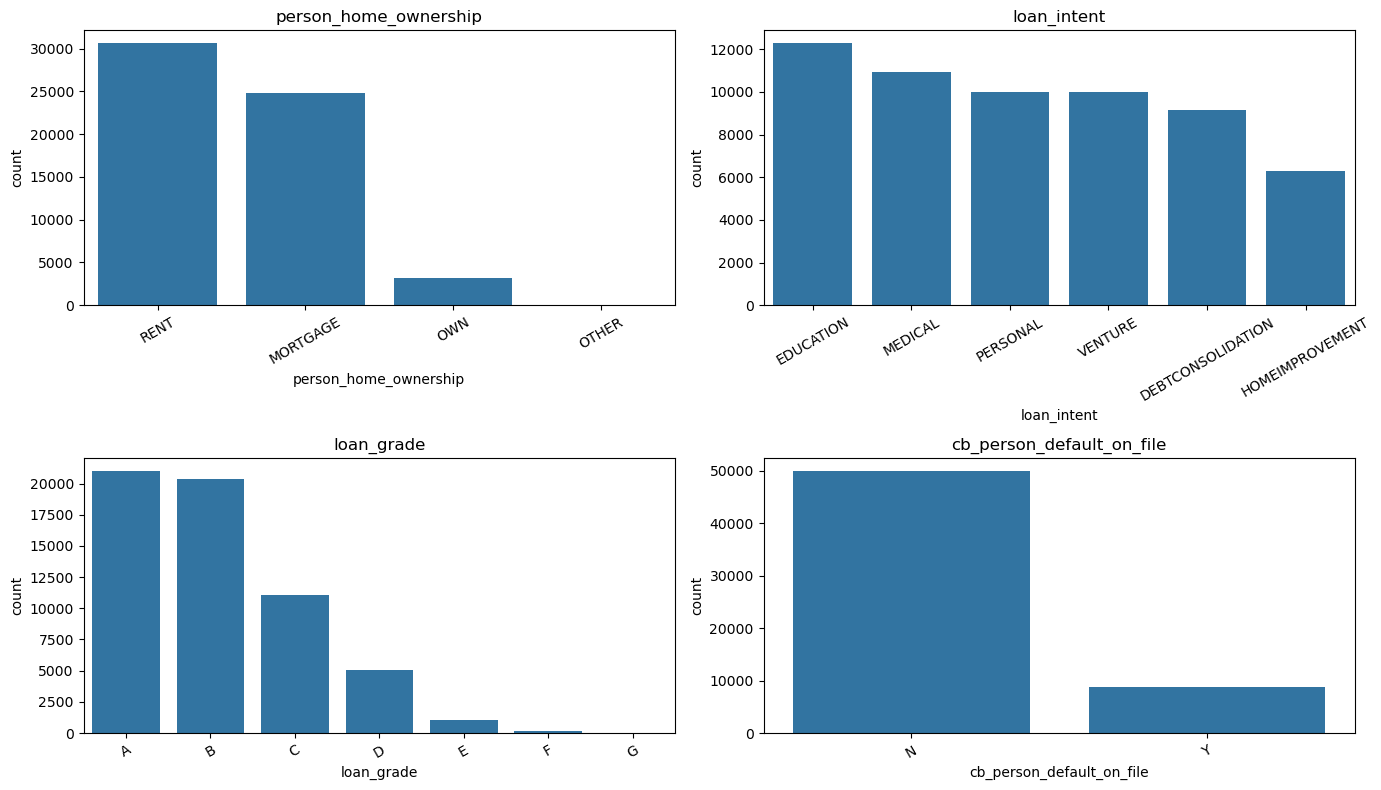

In [7]:
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flatten(), cat_cols):
    order = train[col].value_counts().index
    sns.countplot(x=col, data=train, order=order, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../figures/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Наблюдения:**
- `person_home_ownership`: большинство арендуют (RENT) или в ипотеке (MORTGAGE)
- `loan_intent`: распределение равномерное, чуть больше на образование и медицину
- `loan_grade`: большинство имеют рейтинг A и B, чем хуже рейтинг тем меньше таких заёмщиков
- `cb_person_default_on_file`: около 80% без дефолта (N), 20% с дефолтом (Y)

### 3.6 Признаки в разрезе целевой переменной (Boxplot)

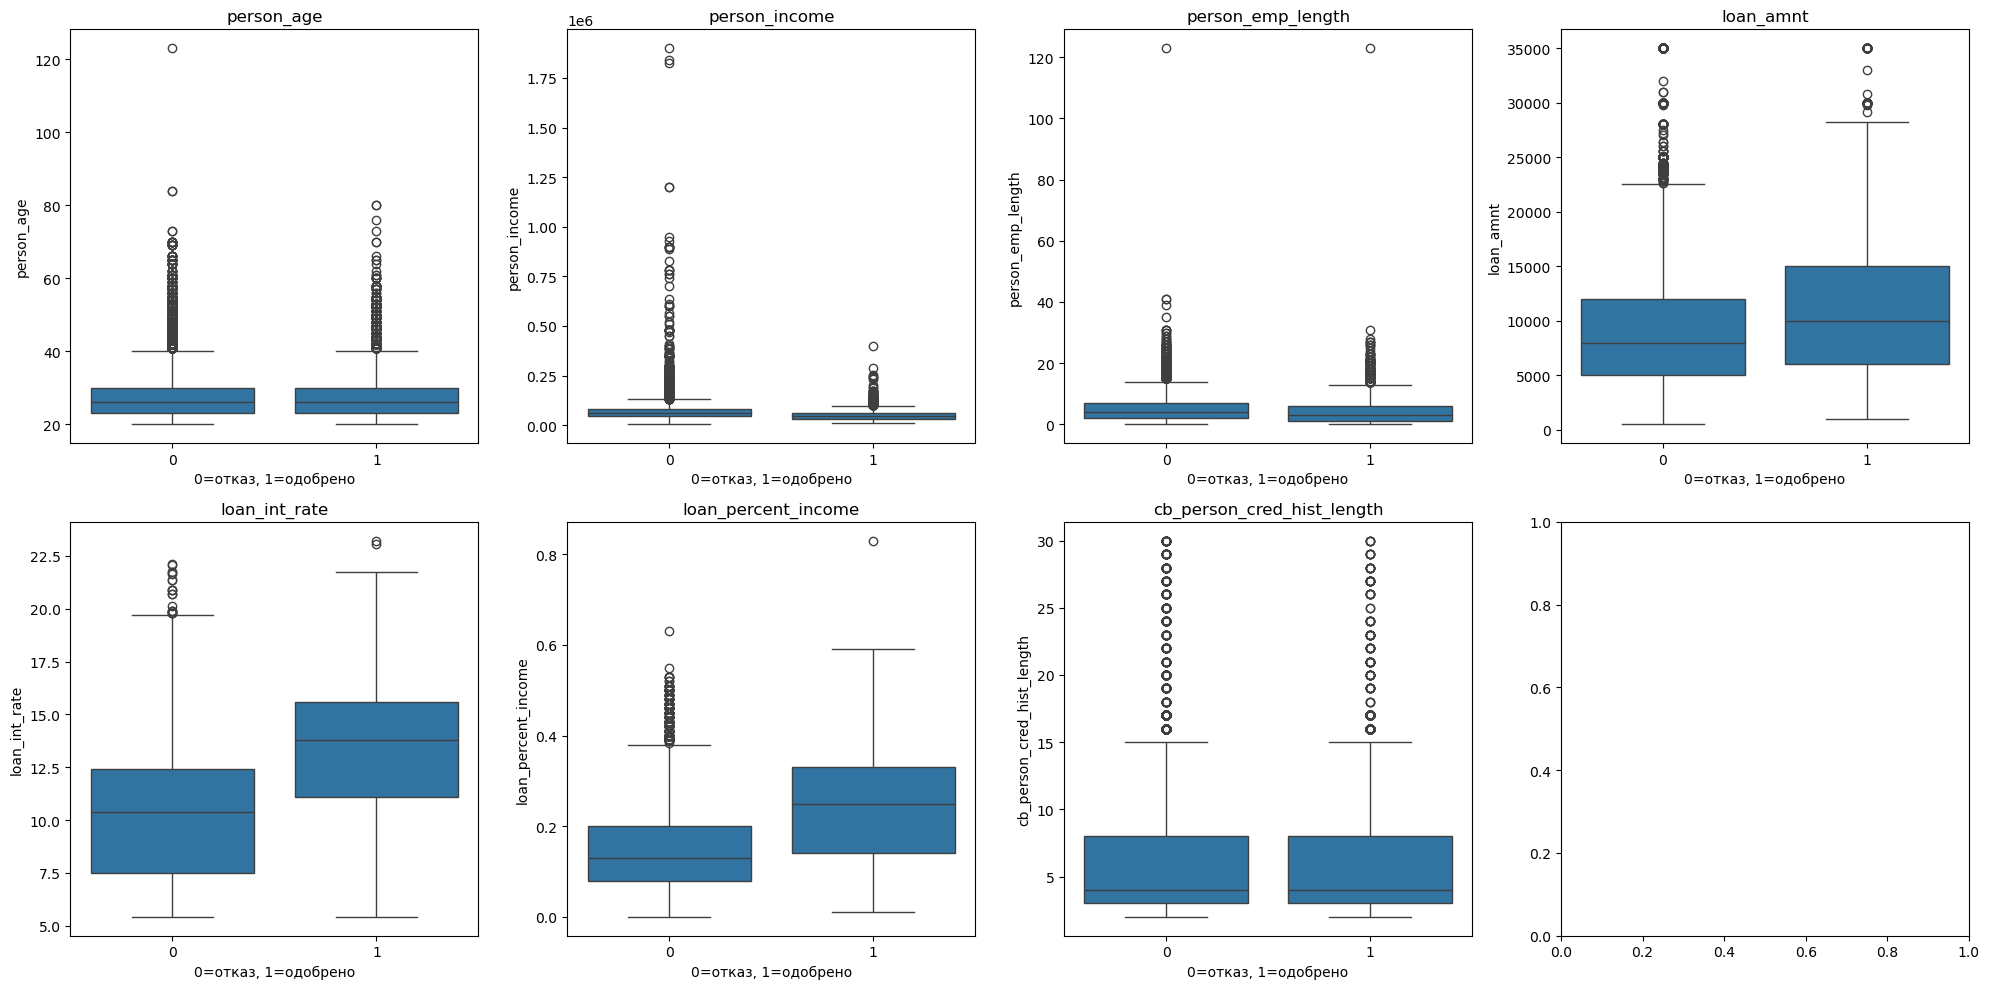

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x='loan_status', y=col, data=train, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('0=отказ, 1=одобрено')

plt.tight_layout()
plt.savefig('../figures/boxplots_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

**Наблюдения:**
- `loan_int_rate`: ставка выше у одобренных 
- `loan_percent_income`: доля кредита от дохода выше у одобренных
- `loan_amnt`: сумма кредита выше у одобренных
- `person_age`, `person_emp_length`: практически нет разницы между классами

### 3.7 Корреляционная матрица

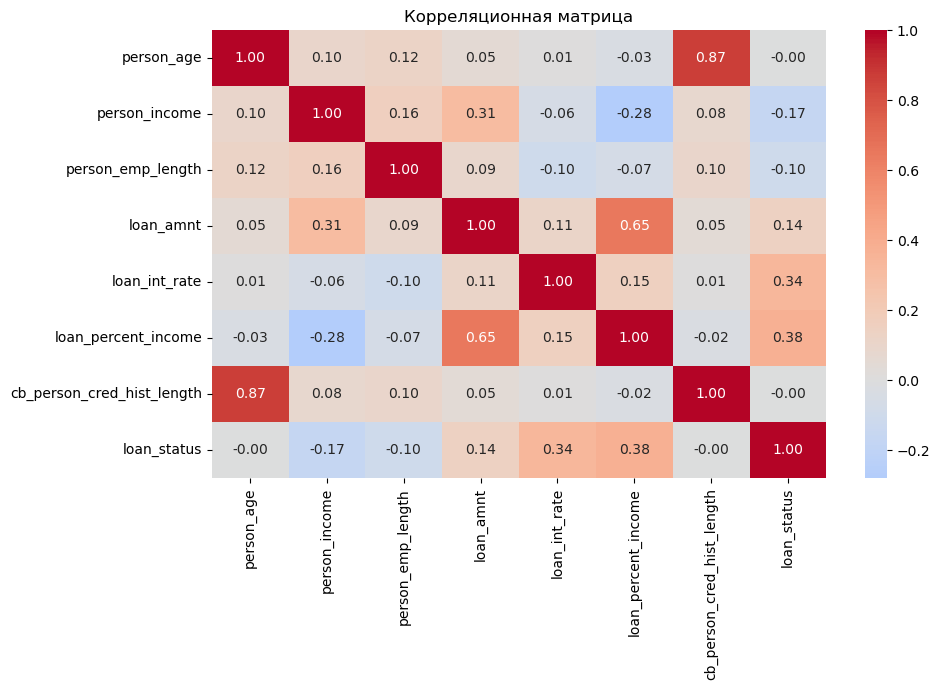

In [9]:
plt.figure(figsize=(10, 7))
corr = train[num_cols + ['loan_status']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.savefig('../figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Выводы по корреляции с `loan_status`:**
- `loan_percent_income`: 0.38 — наибольшая корреляция
- `loan_int_rate`: 0.34 — высокая ставка связана с одобрением
- `person_income`: -0.17 — чем выше доход, тем реже одобряют
- Остальные признаки: корреляция менее 0.15

### Итоговые выводы по EDA

- Датасет содержит 58 645 строк и 13 колонок, пропущенные значения отсутствуют
- Сильный дисбаланс классов: 85.8% отказов, 14.2% одобрений
- Выброс в возрасте: максимум 123 года
- Три признака наиболее коррелируют с целевой переменной: `loan_percent_income`, `loan_int_rate`, `loan_amnt`

---
## 4. Предобработка данных


### 4.1 Удаление колонки id

In [10]:
train = train.drop(columns=['id'])
test = test.drop(columns=['id'])

print('Колонки после удаления id:', train.columns.tolist())

Колонки после удаления id: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'loan_status']


### 4.2 Порядковое кодирование (Ordinal Encoding)

`loan_grade` имеет смысловой порядок (A лучше B, B лучше C и т.д.), поэтому кодируем числами.  
`cb_person_default_on_file` — бинарный признак, кодируем 0 и 1.

In [11]:
grade_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
train['loan_grade'] = train['loan_grade'].map(grade_mapping)
test['loan_grade'] = test['loan_grade'].map(grade_mapping)

default_mapping = {'N': 0, 'Y': 1}
train['cb_person_default_on_file'] = train['cb_person_default_on_file'].map(default_mapping)
test['cb_person_default_on_file'] = test['cb_person_default_on_file'].map(default_mapping)

print(train[['loan_grade', 'cb_person_default_on_file']].head())

   loan_grade  cb_person_default_on_file
0           2                          0
1           3                          0
2           1                          0
3           2                          0
4           1                          0


### 4.3 One-Hot Encoding

`person_home_ownership` и `loan_intent` не имеют порядка, поэтому каждое уникальное значение превращается в отдельную бинарную колонку.

In [12]:
train = pd.get_dummies(train, columns=['person_home_ownership', 'loan_intent'], dtype=int)
test = pd.get_dummies(test, columns=['person_home_ownership', 'loan_intent'], dtype=int)

print('Количество колонок после One-Hot Encoding:', train.shape[1])

Количество колонок после One-Hot Encoding: 20


### 4.4 Разделение на признаки и целевую переменную

In [13]:
X = train.drop(columns=['loan_status'])
y = train['loan_status']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (58645, 19)
y shape: (58645,)


### 4.5 Разделение на train и validation (80/20)

In [14]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)

X_train: (46916, 19)
X_val: (11729, 19)


### 4.6 Нормализация числовых признаков


In [32]:
num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length']

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])  
X_val[num_cols] = scaler.transform(X_val[num_cols])          
test[num_cols] = scaler.transform(test[num_cols])          

print('Предобработка завершена')
print('X_train:', X_train.shape)
print('X_val:', X_val.shape)

Предобработка завершена
X_train: (46916, 19)
X_val: (11729, 19)


---
## 5. Обучение моделей

Обучаем пять моделей классификации и сравниваем их качество. Для работы с дисбалансом классов используем параметр `class_weight='balanced'`.

### 5.1 Logistic Regression

In [16]:
lr_model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)

print('Logistic Regression:')
print(classification_report(y_val, y_pred_lr))
print('ROC-AUC:', roc_auc_score(y_val, lr_model.predict_proba(X_val)[:, 1]))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.97      0.81      0.88     10087
           1       0.41      0.83      0.55      1642

    accuracy                           0.81     11729
   macro avg       0.69      0.82      0.72     11729
weighted avg       0.89      0.81      0.83     11729

ROC-AUC: 0.8966600200665901


### 5.2 Random Forest

In [17]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)

print('Random Forest:')
print(classification_report(y_val, y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_val, rf_model.predict_proba(X_val)[:, 1]))

Random Forest:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     10087
           1       0.93      0.72      0.81      1642

    accuracy                           0.95     11729
   macro avg       0.94      0.85      0.89     11729
weighted avg       0.95      0.95      0.95     11729

ROC-AUC: 0.9387894743261036


### 5.3 Gradient Boosting

In [18]:
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                       max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_val)

print('Gradient Boosting:')
print(classification_report(y_val, y_pred_gb))
print('ROC-AUC:', roc_auc_score(y_val, gb_model.predict_proba(X_val)[:, 1]))

Gradient Boosting:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     10087
           1       0.91      0.72      0.80      1642

    accuracy                           0.95     11729
   macro avg       0.93      0.85      0.89     11729
weighted avg       0.95      0.95      0.95     11729

ROC-AUC: 0.9442966471841145


### 5.4 XGBoost

In [19]:
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                           random_state=42, scale_pos_weight=6, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_val)

print('XGBoost:')
print(classification_report(y_val, y_pred_xgb))
print('ROC-AUC:', roc_auc_score(y_val, xgb_model.predict_proba(X_val)[:, 1]))

XGBoost:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     10087
           1       0.66      0.82      0.73      1642

    accuracy                           0.92     11729
   macro avg       0.81      0.87      0.84     11729
weighted avg       0.93      0.92      0.92     11729

ROC-AUC: 0.9458355727823236


### 5.5 Neural Network (MLP)

In [20]:
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                           max_iter=100, random_state=42, early_stopping=True)
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_val)

print('Neural Network (MLP):')
print(classification_report(y_val, y_pred_mlp))
print('ROC-AUC:', roc_auc_score(y_val, mlp_model.predict_proba(X_val)[:, 1]))

Neural Network (MLP):
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     10087
           1       0.89      0.71      0.79      1642

    accuracy                           0.95     11729
   macro avg       0.92      0.85      0.88     11729
weighted avg       0.94      0.95      0.94     11729

ROC-AUC: 0.9342847555137539


---
## 6. Сравнение моделей

In [21]:
results = {
    'Модель': ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'Neural Network'],
    'ROC-AUC': [
        roc_auc_score(y_val, lr_model.predict_proba(X_val)[:, 1]),
        roc_auc_score(y_val, rf_model.predict_proba(X_val)[:, 1]),
        roc_auc_score(y_val, gb_model.predict_proba(X_val)[:, 1]),
        roc_auc_score(y_val, xgb_model.predict_proba(X_val)[:, 1]),
        roc_auc_score(y_val, mlp_model.predict_proba(X_val)[:, 1])
    ]
}

results_df = pd.DataFrame(results)
results_df['ROC-AUC'] = results_df['ROC-AUC'].round(4)
results_df = results_df.sort_values('ROC-AUC', ascending=False)
print(results_df.to_string(index=False))

             Модель  ROC-AUC
            XGBoost   0.9458
  Gradient Boosting   0.9443
      Random Forest   0.9388
     Neural Network   0.9343
Logistic Regression   0.8967


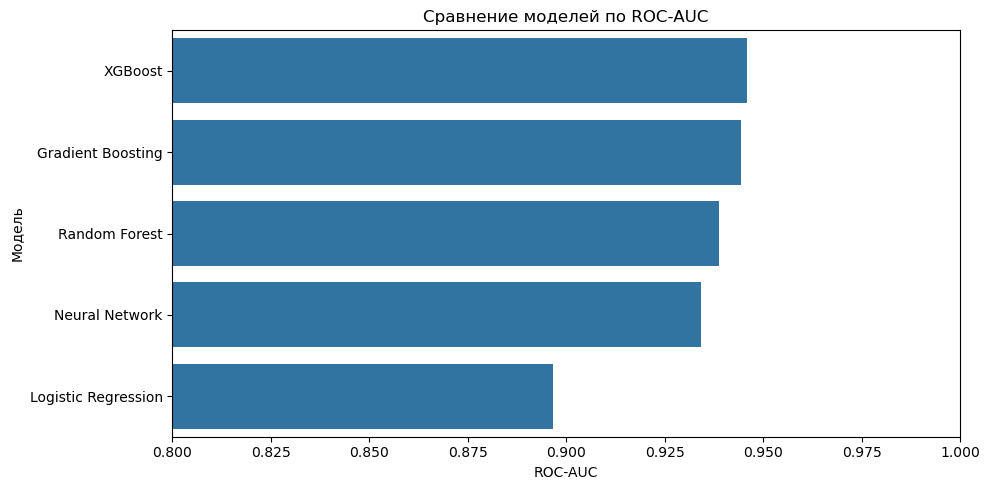

In [22]:
plt.figure(figsize=(10, 5))
sns.barplot(x='ROC-AUC', y='Модель', data=results_df)
plt.title('Сравнение моделей по ROC-AUC')
plt.xlim(0.8, 1.0)
plt.tight_layout()
plt.savefig('../figures/models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Выводы:**
- Лучшая модель по ROC-AUC — **XGBoost**
- Logistic Regression заметно хуже остальных — простая модель не улавливает сложные зависимости
- Random Forest, Gradient Boosting, XGBoost и нейросеть показывают похожие результаты (0.930-0.937)
- Для детального SHAP-анализа выбираем XGBoost как лучшую модель

---
## 7. Feature Importance
Сравниваем важность признаков у трёх моделей на деревьях.

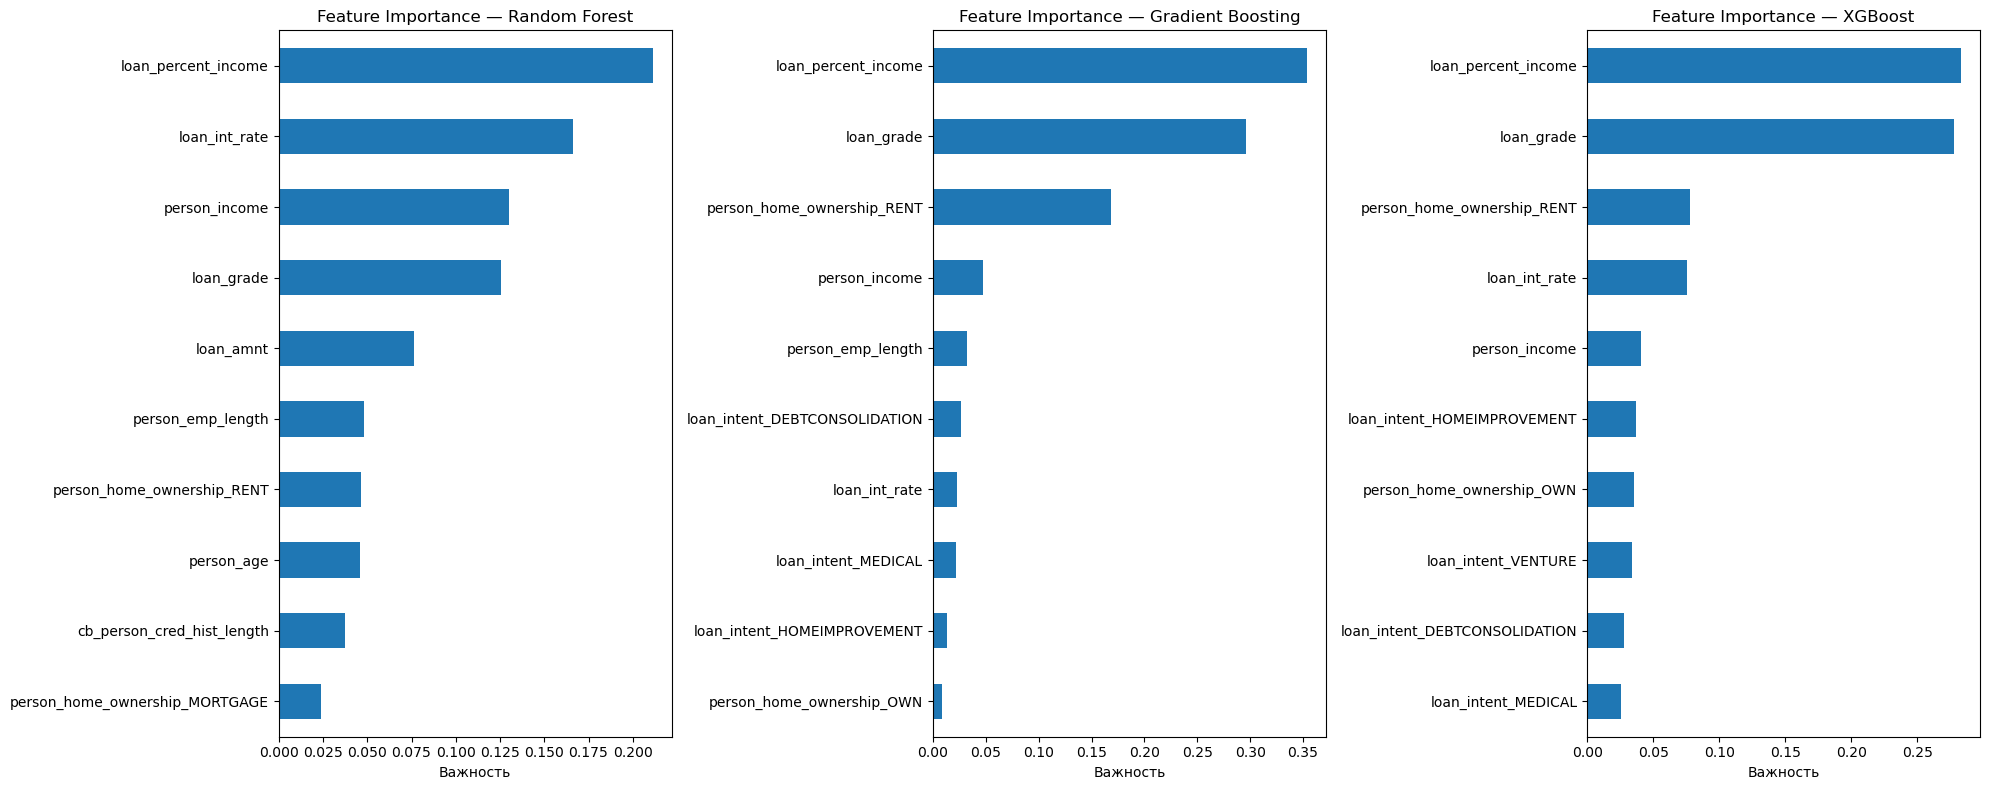

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

models = [rf_model, gb_model, xgb_model]
names = ['Random Forest', 'Gradient Boosting', 'XGBoost']

for ax, model, name in zip(axes, models, names):
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=True).tail(10)
    importances.plot(kind='barh', ax=ax)
    ax.set_title(f'Feature Importance — {name}')
    ax.set_xlabel('Важность')

plt.tight_layout()
plt.savefig('../figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. SHAP-анализ

SHAP (SHapley Additive exPlanations). Применяем к лучшей модели — XGBoost.

### 8.1 Вычисление SHAP значений

In [38]:
explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_val)

print('SHAP values shape:', shap_values.shape)

SHAP values shape: (11729, 19)


### 8.2 Bar Plot — глобальная важность признаков

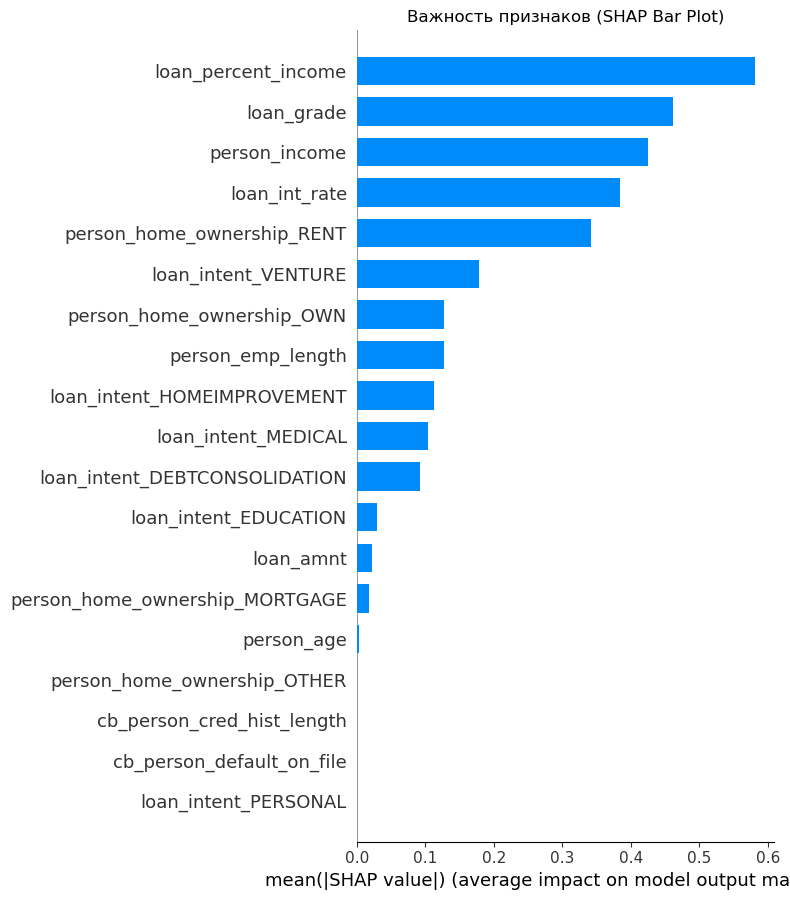

In [39]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val, plot_type='bar', show=False)
plt.title('Важность признаков (SHAP Bar Plot)')
plt.tight_layout()
plt.savefig('../figures/shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Summary Plot — важность и направление влияния

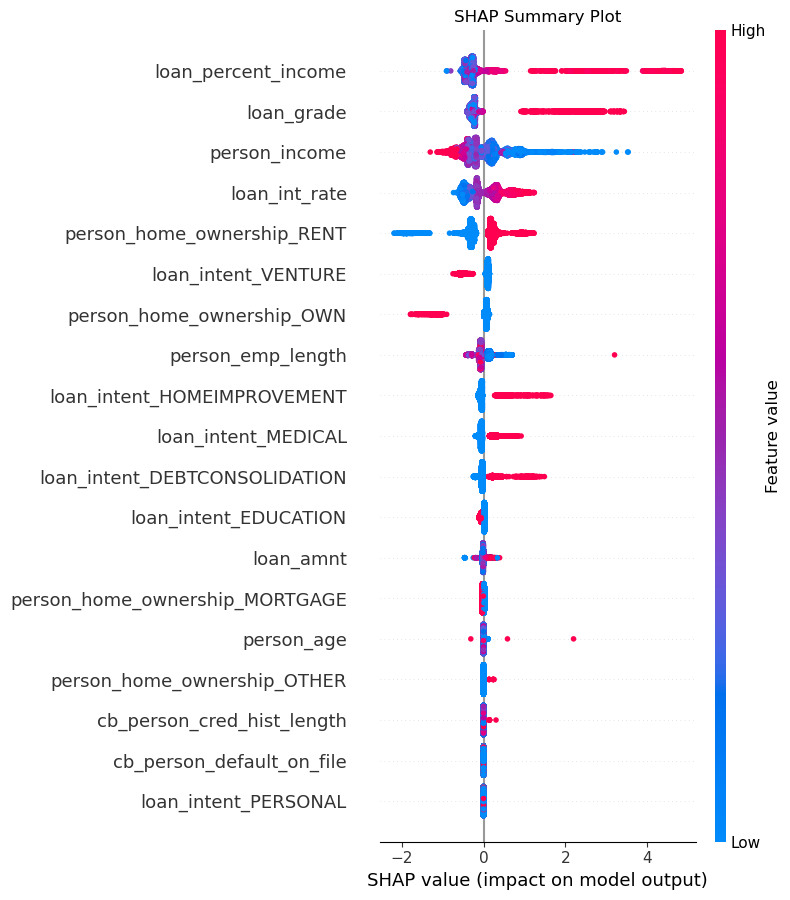

In [40]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.savefig('../figures/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

**Выводы по Summary Plot:**
- `loan_percent_income`: высокая доля кредита от дохода толкает к одобрению
- `loan_grade`: неожиданно — плохой рейтинг (D,E,F,G) связан с одобрением
- `person_income`: высокий доход помогает одобрению, низкий — ведёт к отказу
- `loan_int_rate`: высокая ставка немного помогает одобрению
- `person_home_ownership_RENT`: аренда жилья связана с одобрением

### 8.4 Проверка неожиданной зависимости loan_grade

In [33]:
grade_approval = train.groupby('loan_grade')['loan_status'].mean()
print('Доля одобрений по кредитному рейтингу:')
print(grade_approval)

Доля одобрений по кредитному рейтингу:
loan_grade
1    0.049180
2    0.102304
3    0.135375
4    0.593564
5    0.625372
6    0.610738
7    0.818182
Name: loan_status, dtype: float64


**Вывод:** Заёмщики с плохим рейтингом (D, E, F, G) получают одобрение значительно чаще чем с хорошим (A, B, C). Доля одобрений растёт от 4.9% (рейтинг A) до 81.8% (рейтинг G). Возможное объяснение — банк компенсирует риск высокой процентной ставкой.

### 8.5 Waterfall Plot — локальное объяснение для одного заёмщика

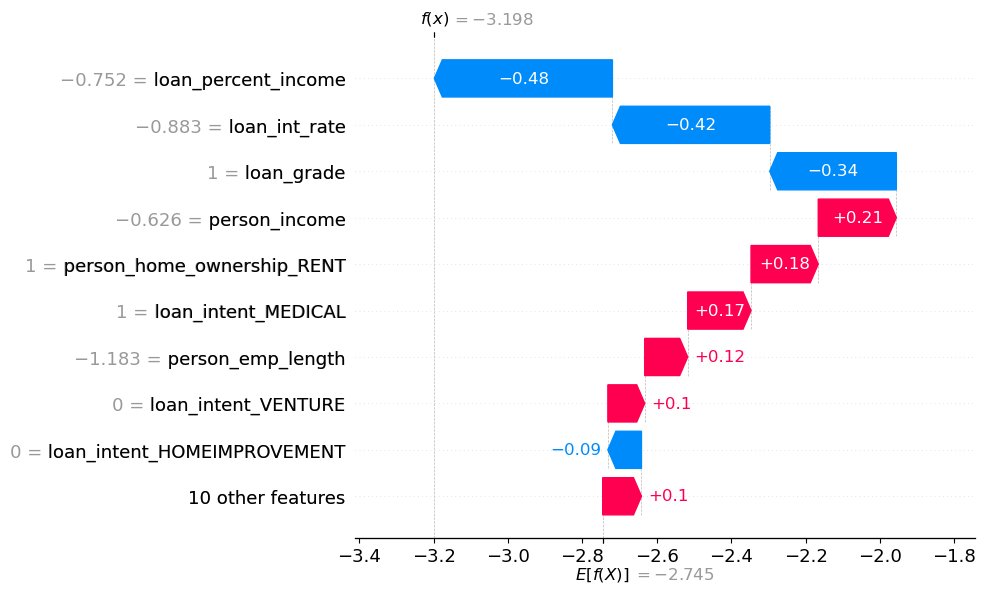

In [41]:
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_val.iloc[0],
    feature_names=X_val.columns.tolist()
), show=False)

plt.savefig('../figures/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Предсказания для test.csv

In [42]:

test_predictions = gb_model.predict_proba(test)[:, 1]

submission = pd.read_csv('../data/sample_submission.csv')
submission['loan_status'] = test_predictions
submission.to_csv('../data/submission.csv', index=False)

print('Предсказания сохранены!')
print(submission.head())

Предсказания сохранены!
      id  loan_status
0  58645     0.909358
1  58646     0.025957
2  58647     0.446765
3  58648     0.023174
4  58649     0.149509


---
## 10. Общие выводы

### Результаты сравнения моделей

| Модель | ROC-AUC | Precision класс 1 | Accuracy |
|--------|---------|-----------|----------|
| Logistic Regression | 0.897 | 0.41 | 0.81 |
| Random Forest | 0.938 | 0.93 | 0.95 |
| Gradient Boosting | 0.944 | 0.91 | 0.95 |
| XGBoost | 0.946 | 0.66 | 0.94 |
| Neural Network | 0.934 | 0.89 | 0.95 |

### Ключевые факторы одобрения кредита (по SHAP)

1. `loan_percent_income` — доля кредита от дохода: самый важный признак
2. `loan_grade` — кредитный рейтинг: неожиданно, плохой рейтинг связан с одобрением
3. `person_income` — годовой доход: высокий доход помогает одобрению
4. `loan_int_rate` — процентная ставка: высокая ставка немного помогает
5. `person_home_ownership_RENT` — аренда жилья: арендаторам одобряют чаще

### Значимость интерпретируемых методов

SHAP позволил не только определить важность признаков, но и выявить неожиданные зависимости в данных (например связь плохого кредитного рейтинга с одобрением). Это демонстрирует ценность интерпретируемых методов для финансовых решений — модель не только предсказывает, но и объясняет свои решения.